## MoE Predictive 
$$
\begin{align}

P_{MoE}(x) &= \sum_{e=1}^E w_e(x) P_e(x)\\ &= \sum_{e=1}^E w_e(x) \int P_\theta(x)dQ_e(\theta)
\end{align}$$


expanding out the $MMD^2$ term:
$$MMD^2(P, P_{MoE}) = \mathbb{E}_{x, x' \sim P}[k(x, x')] - 2 \mathbb{E}_{x \sim P, x' \sim P_{MoE}}[k(x, x')] + \mathbb{E}_{x, x' \sim P_{MoE}}[k(x, x')]$$

$$
\begin{align}
T_{self} &= \iint k(x, x') P_{MoE}(x) P_{MoE}(x') dx dx'\\
 &= \iint k(x, x') \left( \sum_{e=1}^E w_e(x) Q_e(x) \right) \left( \sum_{f=1}^E w_f(x') Q_f(x') \right) dx dx'\\
&= \sum_{e=1}^E \sum_{f=1}^E \iint k(x, x') w_e(x) w_f(x') Q_e(x) Q_f(x') dx dx'\\
&= \underbrace{ \sum_{e=1}^E \iint k(x, x') w_e(x) w_e(x') Q_e(x) Q_e(x') dx dx' }_{\text{Intra-expert: } O(E \cdot n_e^2)} + \underbrace{ \sum_{e \neq f} \iint k(x, x') w_e(x) w_f(x') Q_e(x) Q_f(x') dx dx' }_{\text{Inter-expert: } O(E^2 \cdot n_e^2)}
\end{align}$$


For the speed boost 
$$\mathcal{C}_{ef} = \iint k(x, x') w_e(x) w_f(x') Q_e(x) Q_f(x') dx dx' =0$$

$$

\boxed{
    \text{MMD}^2(P_n, P_{MoE}) = \sum_{e=1}^E \sum_{f=1}^E \iint \kappa_{ef}^{(w)}(\theta, \vartheta)\, dQ_e(\theta)\, dQ_f(\vartheta)
}
$$


so spliting this back up into the terms just involving $Q_e$ for our gradient
$$ = \iint \kappa_{ee}^{(w)}(\theta, \vartheta)\, dQ_e(\theta)\, dQ_e(\vartheta) + 2 \sum_{f \neq e}^E \iint \kappa_{ef}^{(w)}(\theta, \vartheta)\, dQ_e(\theta)\, dQ_f(\vartheta) + \text{Constants w.r.t } Q_e$$

$$
\begin{align*}
\frac{\delta \
dots}{\delta Q_e}(\theta) &= 2 \sum_{f=1}^E \int \kappa_{ef}^{(w)}(\theta, \vartheta)\, dQ_f(\vartheta) \\
\nabla_\theta \left( \frac{\delta \dots}{\delta Q_e}(\theta) \right) &= 2 \sum_{f=1}^E \int \nabla_1 \kappa_{ef}^{(w)}(\theta, \vartheta)\, dQ_f(\vartheta) \\
&\approx 2 \sum_{f=1}^E \left[ \frac{1}{n_f} \sum_{j=1}^{n_f} \nabla_1 \kappa_{ef}^{(w)}(\theta, \vartheta_{f,j}) \right]
\end{align*}
$$

---

## KL divergence term
The global parameter distribution of the Mixture of Experts be the convex combination of the individual expert distributions:$$Q_{MoE}(\theta) = \sum_{e=1}^E \pi_e Q_e(\theta)$$
(Where $\pi_e = \mathbb{E}_x[w_e(x)]$ is the expected routing weight for expert $e$ across the dataset).
$$
\begin{align*}
\mathcal{R}(Q_{1:E}) = \text{KL}(Q_{MoE} || Q_0) &= \int Q_{MoE}(\theta) \log \frac{Q_{MoE}(\theta)}{Q_0(\theta)} d\theta \\
&= \int \sum_{e=1}^E \pi_e Q_e(\theta) \log \left [ \frac{\sum_{e=1}^E \pi_e Q_e(\theta)}{Q_0(\theta)} \right]d\theta
\end{align*}
$$

Taking the derivative.
$$
\begin{align}
\frac{\delta\mathcal{R}(Q_{1:E})}{\delta Q_{MoE}(\theta)} &= \log \frac{Q_{MoE}(\theta)}{Q_0(\theta)} + 1\\
\frac{\delta Q_{MoE}(\theta)}{\delta Q_{e}(\theta)} &= \frac{\delta}{{\delta Q_{e}(\theta)}} \sum_{e=1}^E \pi_e Q_e(\theta) = \pi_e
\end{align}
$$

Combinging (1) and (2) gives the general derivative before applying any MoE assumptions:
$$
\begin{align*}
\frac{\delta \mathcal{R}}{\delta Q_e}(\theta)
&= \pi_e \left( \log \frac{\sum_{f=1}^E \pi_f Q_f(\theta)}{Q_0(\theta)} + 1 \right) \\
&= \pi_e \left( \log \frac{\pi_e Q_e(\theta) + \sum_{f \neq e} \pi_f Q_f(\theta)}{Q_0(\theta)} + 1 \right) \\
&= \pi_e \left( \log \frac{Q_e(\theta)}{Q_0(\theta)} + \log \pi_e + 1 \right),
\quad \text{if experts are non-overlapping.}
\end{align*}
$$
Attempting to Isolate $Q_e(\theta)$ and solve for 0 to find the optimal.. 
$$
\begin{align*}
0 &= V_{Q_e}(\theta) + \lambda \pi_e \left( \log \frac{\pi_e Q_e(\theta) + \sum_{f \neq e} \pi_f Q_f(\theta)}{Q_0(\theta)} + 1 \right) + C \\ 
Q_e^*(\theta) &= \underbrace{\frac{1}{\pi_e Z_e} Q_0(\theta) \exp \left( -\frac{1}{\lambda \pi_e} V_{Q_e}(\theta) \right)}_{\text{Standard Gibbs Term}} - \underbrace{\sum_{f \neq e} \frac{\pi_f}{\pi_e} Q_f(\theta)}_{\text{Interference Term}}
\end{align*}
$$
<!-- $$\frac{\delta \mathcal{R}}{\delta Q_e}(\theta) = \frac{\delta}{\delta Q_e} \int \left( \sum_f \pi_f Q_f(\theta) \right) \log \frac{\sum_f \pi_f Q_f(\theta)}{Q_0(\theta)} d\theta$$ -->

We now have the update gradients for each expert and globally:
\begin{align}
    \nabla_\theta \left( \frac{\delta \mathcal{R}}{\delta Q_e}(\theta) \right) &= \nabla_\theta \log \frac{Q_{MoE}(\theta)}{Q_0(\theta)} \nonumber \\
    &= \pi_e \nabla_\theta \log \left( \sum_{f=1}^E \pi_f Q_f(\theta) \right) - \pi_e \nabla_\theta \log Q_0(\theta) \\ 
    \nabla_\theta \left( \frac{\delta \mathcal{R}}{\delta Q_{MoE}}(\theta) \right) &= \nabla_\theta \log Q_{MoE}(\theta) - \nabla_\theta \log Q_0(\theta) 
\end{align}


> ALSO $$\log Q_{MoE}(\theta) = \log \left( Q_e(\theta) \frac{Q_{MoE}(\theta)}{Q_e(\theta)} \right) = \log Q_e(\theta) + \log \left( \frac{Q_{MoE}(\theta)}{Q_e(\theta)} \right)$$ $$\nabla_\theta \log Q_{MoE}(\theta) = \underbrace{\nabla_\theta \log Q_e(\theta)}_{\text{Self-Entropy}} + \underbrace{\nabla_\theta \log \left( \frac{Q_{MoE}(\theta)}{Q_e(\theta)} \right)}_{\text{Cross-Entropy / True Repulsion}}$$

so what was (1) should be $$\begin{equation}\nabla_\theta \left( \frac{\delta \mathcal{R}}{\delta Q_e}(\theta) \right) = \pi_e \nabla_\theta \log Q_0(\theta) - \pi_e \nabla_\theta \log Q_e(\theta) - \pi_e \nabla_\theta \log \left( \frac{Q_{MoE}(\theta)}{Q_e(\theta)} \right)\end{equation}$$

<div style="color: red;">

Because $\mathcal{R}$ is a functional (a mapping that takes a distribution as an input and returns a scalar), you must use the functional derivative symbol ($\delta$). Using $\partial$ implies standard multivariable calculus.

</div>

The Prior Force: $\pi_e \nabla_\theta \log Q_0(\theta)$ pulls the particles towards regions of high prior probability.The Repulsive/Interference Force: $- \pi_e \nabla_\theta \log \left( \sum_{f=1}^E \pi_f Q_f(\theta) \right)$ acts as a repulsive force. It pushes the particles of expert $e$ away from regions already heavily populated by the global mixture, forcing the experts to specialise and become non-overlapping.

### Time Discretisation

let $\theta_{e,i}^{(t)}$ denote the position of the $i$-th particle for expert $e$ at iteration $t$.

To discretise this over time, we apply a standard Forward Euler update with a step size (or learning rate) $\eta$:

$$\theta_{e,i}^{(t+1)} = \theta_{e,i}^{(t)} - \eta \nabla_\theta \left( \frac{\delta \mathcal{R}}{\delta Q_e} (\theta_{e,i}^{(t)}) \right)$$

Subbing in (1)
$$\theta_{e,i}^{(t+1)} = \theta_{e,i}^{(t)} + \eta_e \left[ \nabla_\theta \log Q_0(\theta_{e,i}^{(t)}) - \nabla_\theta \log \left( \frac{\tilde{Q}_{MoE}(\theta_{e,i}^{(t)})}{\tilde{Q}_e(\theta_{e,i}^{(t)})} \right) \right] + \sqrt{2\eta_e} \epsilon_{e,i}^{(t)}$$


where $\tilde{Q}_{MoE}(\theta) = \sum_{f=1}^E \pi_f \left( \frac{1}{N} \sum_{j=1}^N K_h(\theta, \theta_{f,j}^{(t)}) \right)$ Kernel Density Estimate for the aproximation and where $\epsilon_{e,i}^{(t)} \sim \mathcal{N}(0, I)$.

## MMD + KL
$$\begin{align}\theta_{e,i}^{(t+1)} = \theta_{e,i}^{(t)} + \eta_e \left[ \nabla_\theta \log Q_0(\theta_{e,i}^{(t)}) - \nabla_\theta \log \left( \frac{\tilde{Q}_{MoE}(\theta_{e,i}^{(t)})}{\tilde{Q}_e(\theta_{e,i}^{(t)})} \right) \right] + \sqrt{2\eta_e} \epsilon_{e,i}^{(t)} \\


 Grad MMD = 2 \sum_{f=1}^E \left[ \frac{1}{n_f} \sum_{j=1}^{n_f} \nabla_1 \kappa_{ef}^{(w)}(\theta, \vartheta_{f,j}) \right]\end{align}
$$

(1)+(2)
$$\theta_{e,i}^{(t+1)} = \theta_{e,i}^{(t)} + \eta_e \left[ \underbrace{ - \sum_{f=1}^E \frac{1}{n_f} \sum_{j=1}^{n_f} \nabla_1 \kappa_{ef}^{(w)}(\theta_{e,i}^{(t)}, \vartheta_{f,j}^{(t)})}_{\text{MMD Particle Interactions (Descent)}} + \underbrace{\lambda \pi_e \nabla_\theta \log Q_0(\theta_{e,i}^{(t)})}_{\text{Prior Attraction}} - \underbrace{\lambda \pi_e \nabla_\theta \log \left( \frac{\tilde{Q}_{MoE}(\theta_{e,i}^{(t)})}{\tilde{Q}_e(\theta_{e,i}^{(t)})} \right)}_{\text{Inter-Expert Repulsion}} \right] + \underbrace{\sqrt{2\eta_e \lambda \pi_e} \epsilon_{e,i}^{(t)}}_{\text{Langevin Noise}}$$

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup & Hyperparameters ---
N = 200        # Particles per expert
E = 2           # Number of experts
eta = 0.05      # Base step size (learning rate)
h = 0.5         # Kernel bandwidth for KDE
steps = 1000    # Simulation steps

# Equal routing weights for simplicity
pi = np.array([.5, .5])

# Initialise particles for 2 experts (Shape: E x N)
theta = np.random.randn(E, N) * 2.0  # Start them spread out

# --- 2. Helper: 1D KDE and its spatial gradient ---
def compute_kde_and_grad(eval_points, particles, bandwidth):
    """Calculates empirical density and its gradient using a Gaussian kernel."""
    # Broadcasting to get pairwise differences: shape (N, N)
    diff = eval_points[:, None] - particles[None, :] 
    kernel = np.exp(-0.5 * (diff / bandwidth)**2)
    
    # Add a tiny epsilon to density to prevent division by zero later
    density = kernel.mean(axis=1) + 1e-8  
    grad_density = (-diff / bandwidth**2 * kernel).mean(axis=1)
    
    return density, grad_density

# --- 3. The Main Langevin Dynamics Loop ---
for t in range(steps):
    theta_next = np.zeros_like(theta)
    
    for e in range(E):
        particles_e = theta[e]
        eta_e = eta * pi[e]  # Expert-specific step size
        
        # Force 1: Prior Attraction
        # Assuming a standard normal prior N(0, 1), the grad of log prior is just -x
        prior_grad = -particles_e
        
        # Force 2: Global Repulsion (Cross-Entropy)
        # First, compute Q_e density and gradient at current particle locations
        q_e, grad_q_e = compute_kde_and_grad(particles_e, particles_e, h)
        
        # Next, compute global Q_MoE density and gradient at the SAME locations
        q_moe = np.zeros(N)
        grad_q_moe = np.zeros(N)
        for f in range(E):
            q_f, grad_q_f = compute_kde_and_grad(particles_e, theta[f], h)
            q_moe += pi[f] * q_f
            grad_q_moe += pi[f] * grad_q_f
            
        # Repulsion = grad log (Q_MoE / Q_e) = (grad Q_MoE / Q_MoE) - (grad Q_e / Q_e)
        repulsion_grad = (grad_q_moe / q_moe) - (grad_q_e / q_e)
        
        # Force 3: Brownian Exploration
        noise = np.sqrt(2 * eta_e) * np.random.randn(N)
        
        # --- The Discrete ULA Update ---
        theta_next[e] = particles_e + eta_e * (prior_grad - repulsion_grad) + noise
        
    theta = theta_next # Synchronous update

print("Simulation complete. Final particle distributions:")
print(f"Expert 1 Mean: {theta[0].mean():.3f}, Std: {theta[0].std():.3f}")
print(f"Expert 2 Mean: {theta[1].mean():.3f}, Std: {theta[1].std():.3f}")

Simulation complete. Final particle distributions:
Expert 1 Mean: -0.145, Std: 1.107
Expert 2 Mean: 0.041, Std: 0.975


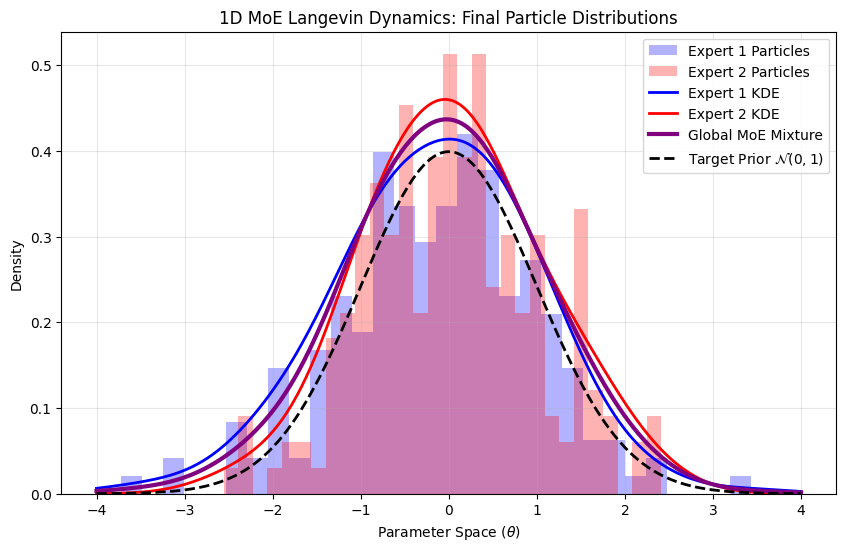

In [59]:
plt.figure(figsize=(10, 6))
x_eval = np.linspace(-4, 4, 300)

kde_1, _ = compute_kde_and_grad(x_eval, theta[0], h)
kde_2, _ = compute_kde_and_grad(x_eval, theta[1], h)
kde_moe = pi[0] * kde_1 + pi[1] * kde_2
prior = np.exp(-0.5 * x_eval**2) / np.sqrt(2 * np.pi)

plt.hist(theta[0], bins=30, alpha=0.3, density=True, color='blue', label='Expert 1 Particles')
plt.hist(theta[1], bins=30, alpha=0.3, density=True, color='red', label='Expert 2 Particles')

plt.plot(x_eval, kde_1, color='blue', linewidth=2, label='Expert 1 KDE')
plt.plot(x_eval, kde_2, color='red', linewidth=2, label='Expert 2 KDE')
plt.plot(x_eval, kde_moe, color='purple', linewidth=3, linestyle='-', label='Global MoE Mixture')
plt.plot(x_eval, prior, 'k--', linewidth=2, label='Target Prior $\mathcal{N}(0,1)$')

plt.title('1D MoE Langevin Dynamics: Final Particle Distributions')
plt.xlabel('Parameter Space ($\\theta$)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

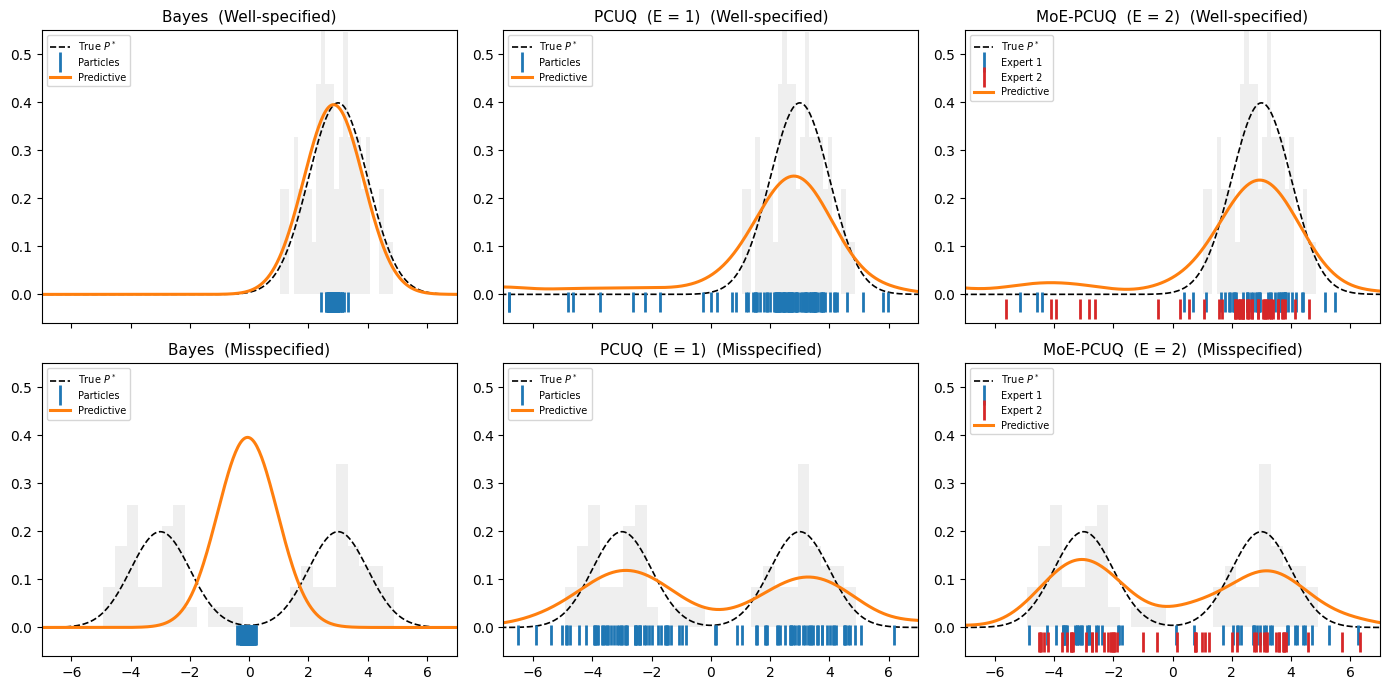

In [50]:
"""
MoE-PCUQ minimal demo.

Model family: P_theta(y) = N(y; theta, sigma^2)   (1D Gaussian, known variance)
Kernel:       k(y,y') = exp(-|y-y'|^2 / (2 ell^2)) (Gaussian on Y)

All kernel integrals analytic (PCUQ Appendix D).
Gradient flow discretised via Euler-Maruyama (PCUQ eq 9, Wild et al. eq 59).
"""
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

np.random.seed(42)

# ── Kernel integrals (PCUQ Appendix D, p=1) ─────────────────────────

def alpha(y, th, ell, sig):
    s = ell**2 + sig**2
    return np.sqrt(ell**2 / s) * np.exp(-(y - th)**2 / (2 * s))

def grad_alpha(y, th, ell, sig):
    s = ell**2 + sig**2
    return alpha(y, th, ell, sig) * (y - th) / s

def beta(th1, th2, ell, sig):
    s = ell**2 + 2 * sig**2
    return np.sqrt(ell**2 / s) * np.exp(-(th1 - th2)**2 / (2 * s))

def grad_beta(th1, th2, ell, sig):
    s = ell**2 + 2 * sig**2
    return -beta(th1, th2, ell, sig) * (th1 - th2) / s


# ── Bayes (analytic Gaussian posterior) ──────────────────────────────

def bayes_particles(data, N, sig, sig0):
    n = len(data)
    prec_post = n / sig**2 + 1 / sig0**2
    mu_post = (data.sum() / sig**2) / prec_post
    sig_post = 1.0 / np.sqrt(prec_post)
    return np.random.randn(N) * sig_post + mu_post


# ── PCUQ  (E=1, PCUQ eq 9) ──────────────────────────────────────────

def run_pcuq(data, N, T, eta, lam, ell, sig, sig0):
    th = np.random.randn(N) * 2
    n = len(data)
    for _ in tqdm(range(T)):
        # grad_alpha: (N, n) -> mean over data -> (N,)
        ga = grad_alpha(data[None, :], th[:, None], ell, sig).mean(1)
        # grad_beta:  (N, N) with self excluded (PCUQ eq 9)
        gb = grad_beta(th[:, None], th[None, :], ell, sig)
        np.fill_diagonal(gb, 0)
        gb = gb.sum(1) / max(N - 1, 1)

        g_mmd = -ga + gb                       # Wasserstein grad of MMD²
        g_prior = -th / sig0**2                 # grad log Q0
        th -= eta * (g_mmd - lam * g_prior)     # descent
        th += np.sqrt(2 * eta * lam) * np.random.randn(N)  # Langevin noise
    return th


# ── MoE-PCUQ  (E experts, pi_e = 1/E, iid data) ────────────────────

def run_moe_pcuq(data, E, Nper, T, eta, lam, ell, sig, sig0):
    experts = [np.random.randn(Nper) * 2 for _ in range(E)]
    pi = 1.0 / E
    n = len(data)

    for _ in tqdm(range(T)):
        new = []
        for e in range(E):
            th_e = experts[e].copy()

            # ---- MMD gradient (first variation w.r.t. Q_e) ----
            # -pi_e/n  sum_i grad_alpha_i(th)
            ga = grad_alpha(data[None, :], th_e[:, None], ell, sig).mean(1)

            # +pi_e * sum_f pi_f * (1/Nf) sum_j grad_beta(th, th_{f,j})
            gb = np.zeros(Nper)
            for f in range(E):
                gb_ef = grad_beta(th_e[:, None], experts[f][None, :], ell, sig)
                if f == e:
                    np.fill_diagonal(gb_ef, 0)
                    gb += pi * gb_ef.sum(1) / max(Nper - 1, 1)
                else:
                    gb += pi * gb_ef.mean(1)

            g_mmd = pi * (-ga + gb)

            # ---- KL: prior + noise (self-entropy absorbed into diffusion) ----
            g_prior = -th_e / sig0**2

            th_e -= eta * (g_mmd - lam * pi * g_prior)
            th_e += np.sqrt(2 * eta * lam * pi) * np.random.randn(Nper)
            new.append(th_e)
        experts = new
    return experts


# ── Predictive helpers ───────────────────────────────────────────────

def pred(y, particles, sig):
    p = np.exp(-(y[:, None] - particles[None, :]) ** 2 / (2 * sig**2))
    return p.mean(1) / (np.sqrt(2 * np.pi) * sig)

def moe_pred(y, experts, sig):
    return np.mean([pred(y, ex, sig) for ex in experts], axis=0)


# ── Data ─────────────────────────────────────────────────────────────

sig = 1.0;  n = 60

data_well = np.random.randn(n) * sig + 3.0                         # N(3,1)
mix = np.random.binomial(1, 0.5, n)
data_mis  = np.where(mix, 3, -3) + np.random.randn(n) * sig        # bimodal

# ── Run ──────────────────────────────────────────────────────────────

N = 100;  E = 2;  Nper = N // E
ell = sig;  sig0 = 5.0;  lam = 0.05;  T = 4000;  eta = 0.08

results = {}
for label, data in [("well", data_well), ("mis", data_mis)]:
    results[label] = {
        "bayes": bayes_particles(data, N, sig, sig0),
        "pcuq":  run_pcuq(data, N, T, eta, lam, ell, sig, sig0),
        "moe":   run_moe_pcuq(data, E, Nper, T, eta, lam, ell, sig, sig0),
    }

# ── Plot ─────────────────────────────────────────────────────────────

y_grid = np.linspace(-8, 8, 400)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)

titles = ["Bayes", "PCUQ  (E = 1)", "MoE-PCUQ  (E = 2)"]

for row, (label, dname) in enumerate([("well", "Well-specified"), ("mis", "Misspecified")]):
    data = data_well if label == "well" else data_mis
    # true density
    if label == "well":
        true_p = np.exp(-(y_grid - 3)**2 / 2) / np.sqrt(2*np.pi)
    else:
        true_p = 0.5 * np.exp(-(y_grid - 3)**2 / 2) / np.sqrt(2*np.pi) + \
                 0.5 * np.exp(-(y_grid + 3)**2 / 2) / np.sqrt(2*np.pi)

    for col, method in enumerate(["bayes", "pcuq", "moe"]):
        ax = axes[row, col]
        ax.hist(data, bins=25, density=True, alpha=0.25, color="silver", zorder=0)
        ax.plot(y_grid, true_p, "k--", lw=1.2, label="True $P^*$")

        r = results[label][method]
        if method == "moe":
            p = moe_pred(y_grid, r, sig)
            cols = ["tab:blue", "tab:red"]
            for e, ex in enumerate(r):
                ax.plot(ex, -0.015 * (e + 1) * np.ones_like(ex),
                        "|", ms=14, mew=2, color=cols[e],
                        label=f"Expert {e+1}")
        else:
            p = pred(y_grid, r, sig)
            ax.plot(r, -0.015 * np.ones_like(r),
                    "|", ms=14, mew=2, color="tab:blue", label="Particles")

        ax.plot(y_grid, p, color="tab:orange", lw=2.2, label="Predictive")
        ax.set_title(f"{titles[col]}  ({dname})", fontsize=11)
        ax.set_xlim(-7, 7);  ax.set_ylim(-0.06, 0.55)
        ax.legend(fontsize=7, loc="upper left")

fig.tight_layout()
# fig.savefig("/mnt/user-data/outputs/moe_pcuq_demo.png", dpi=150, bbox_inches="tight")
# print("saved.")
plt.show()

$$\begin{align*}
\delta_{e,i} = \frac{\partial \mathcal{L}}{\partial w_e(x_i)} &= \frac{1}{n} \Bigg[ \underbrace{ \sum_{f=1}^E \pi_f \left( \frac{1}{n_e n_f} \sum_{p=1}^{n_e} \sum_{q=1}^{n_f} k(\theta_{e,p}, \vartheta_{f,q}) \right) - \frac{1}{n_e} \sum_{p=1}^{n_e} k(x_i, \theta_{e,p}) }_{\text{MMD Routing Forces}} \\
&\quad + \underbrace{ \lambda_n \frac{1}{n_e} \sum_{p=1}^{n_e} \left( \log \frac{\tilde{Q}_{MoE}(\theta_{e,p})}{Q_0(\theta_{e,p})} + 1 \right) }_{\text{KL Penalty}} \\
&\quad + \underbrace{ \lambda_1 (\log \pi_e + 1) - \lambda_2 (\log w_e(x_i) + 1) }_{\text{Routing Regularizers}} \Bigg]
\end{align*}$$

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0 | Gate Splitting Ratio: 0.79 / 0.21
Epoch 200 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 400 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 600 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 800 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1000 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1200 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1400 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1600 | Gate Splitting Ratio: 0.50 / 0.50
Epoch 1800 | Gate Splitting Ratio: 0.50 / 0.50


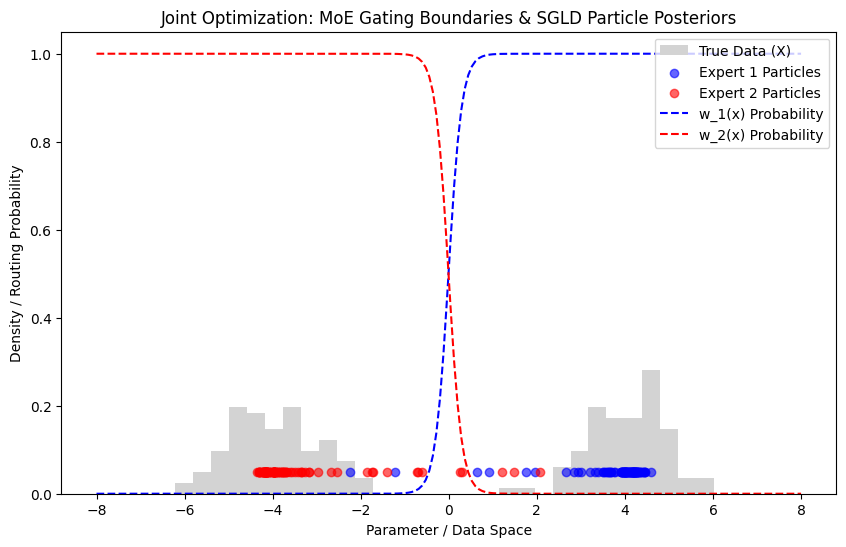

In [72]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup & Hyperparameters
# ==========================================
torch.manual_seed(42)

# Training params
n_epochs = 2000
n_particles = 100         # Particles per expert
lr_particles = 0.05      # eta for SGLD
lr_gate = 0.05           # Learning rate for Adam
lambda_prior = 0.001       # KL Prior strength
lambda_entropy = 0.1     # Load balancing penalty

# Generate Toy Data: Two distinct clusters at -4 and +4
X_data = torch.cat([
    torch.randn(100, 1) - 4.0, 
    torch.randn(100, 1) + 4.0
])
N_data = X_data.shape[0]

# Initialize Particles for 2 Experts (requires_grad=True for SGLD)
# We initialize them randomly near the center
theta_1 = (torch.randn(n_particles, 1) - 0.0).requires_grad_(True)
theta_2 = (torch.randn(n_particles, 1) + 0.0).requires_grad_(True)

# Define the Gating Network (Soft Boundaries)
gate_net = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 2),
    nn.Softmax(dim=1) # Outputs [w_1(x), w_2(x)]
)
gate_optimizer = torch.optim.Adam(gate_net.parameters(), lr=lr_gate)

# ==========================================
# 2. The MMD / Kernel Functions
# ==========================================
def rbf_kernel(X, Y, h=15.0):
    """Standard RBF Kernel: exp(-||x-y||^2 / h)"""
    XX = (X ** 2).sum(dim=1, keepdim=True)
    YY = (Y ** 2).sum(dim=1, keepdim=True)
    dist = XX + YY.t() - 2 * X @ Y.t()
    return torch.exp(-dist / h)

def compute_mmd_loss(X, theta_1, theta_2, gate_weights):
    """
    Computes the PCUQ MoE MMD exactly as derived in your 'MoE Dynamics' doc.
    gate_weights shape: [N_data, 2]
    """
    # Average routing weights across the dataset (pi_e)
    pi_1 = gate_weights[:, 0].mean()
    pi_2 = gate_weights[:, 1].mean()
    
    # 1. Model-to-Model Interaction (The Block Diagonal Approximation)
    # Note: We decouple the experts here to get the O(E * n^2) shortcut!
    k_11 = rbf_kernel(theta_1, theta_1).mean()
    k_22 = rbf_kernel(theta_2, theta_2).mean()
    model_interaction = (pi_1**2 * k_11) + (pi_2**2 * k_22)
    
    # 2. Data-to-Model Interaction (The Routing Forces)
    k_X1 = rbf_kernel(X, theta_1).mean(dim=1) # shape [N_data]
    k_X2 = rbf_kernel(X, theta_2).mean(dim=1) # shape [N_data]
    
    # Weight the kernel interactions by the gate probabilities for each point
    data_interaction = (gate_weights[:, 0] * k_X1).mean() + \
                       (gate_weights[:, 1] * k_X2).mean()
    
    # 3. Data-to-Data (Constant, so we ignore it for optimization)
    # MMD^2 = Model_Interaction - 2 * Data_Interaction
    return model_interaction - 2 * data_interaction

# ==========================================
# 3. The Alternating Joint Training Loop
# ==========================================
for epoch in tqdm(range(n_epochs)):
    
    # Forward pass: Get routing weights for the batch
    gate_weights = gate_net(X_data) 
    pi_1 = gate_weights[:, 0].mean().item()
    pi_2 = gate_weights[:, 1].mean().item()
    
    # ---------------------------------------------------------
    # PHASE A: Update Particles (SGLD) - Freezing the Gate
    # ---------------------------------------------------------
    # 1. Compute the exact MMD spatial gradients via autograd
    loss_mmd = compute_mmd_loss(X_data, theta_1, theta_2, gate_weights.detach())
    loss_mmd.backward()
    
    with torch.no_grad(): # Apply the physical update rules manually
        for idx, (theta_e, pi_e) in enumerate([(theta_1, pi_1), (theta_2, pi_2)]):
            
            # THE FIX: Scale the PyTorch gradient back to the theoretical Expectation
            force_mmd = -theta_e.grad * (n_particles / 2.0)
            
            # The Prior Drift (Standard Gaussian N(0,1) weight decay)
            force_prior = -theta_e 
            
            # Combine drifts 
            drift = force_mmd + (lambda_prior * pi_e * force_prior)
            
            # The SGLD Noise 
            noise_scale = torch.sqrt(torch.tensor(2 * lr_particles * lambda_prior * pi_e))
            noise = noise_scale * torch.randn_like(theta_e)
            
            # SGLD Step
            theta_e.add_(lr_particles * drift + noise)
            
            # Zero out gradients for the next loop
            theta_e.grad.zero_()
    # ---------------------------------------------------------
    # PHASE B: Update Gate (Adam) - Freezing the Particles
    # ---------------------------------------------------------
    gate_optimizer.zero_grad()
    
    # 1. Recompute MMD loss with detached particles to get routing error signal
    loss_gate_mmd = compute_mmd_loss(X_data, theta_1.detach(), theta_2.detach(), gate_weights)
    
    # 2. Add Load Balancing (Marginal Entropy) to prevent Routing Collapse
    # This matches your "MoE MMD Architectural Crossroads" document
    pi_tensor = gate_weights.mean(dim=0) 
    loss_entropy = - torch.sum(pi_tensor * torch.log(pi_tensor + 1e-8))
    
    # Total Gate Loss
    total_gate_loss = loss_gate_mmd - (lambda_entropy * loss_entropy)
    
    # Backpropagate through the neural network and update weights
    total_gate_loss.backward()
    gate_optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Gate Splitting Ratio: {pi_1:.2f} / {pi_2:.2f}")

# ==========================================
# 4. Visualization
# ==========================================
with torch.no_grad():
    # Plotting the data and particles
    plt.figure(figsize=(10, 6))
    plt.hist(X_data.numpy(), bins=30, density=True, color='lightgray', label='True Data (X)')
    
    # Plot Expert 1 Posterior
    plt.scatter(theta_1.numpy(), [0.05]*n_particles, color='blue', alpha=0.6, label='Expert 1 Particles')
    
    # Plot Expert 2 Posterior
    plt.scatter(theta_2.numpy(), [0.05]*n_particles, color='red', alpha=0.6, label='Expert 2 Particles')
    
    # Plot the Gating Network's Decision Boundary
    x_range = torch.linspace(-8, 8, 200).unsqueeze(1)
    gate_probs = gate_net(x_range)
    plt.plot(x_range.numpy(), gate_probs[:, 0].numpy(), color='blue', linestyle='--', label='w_1(x) Probability')
    plt.plot(x_range.numpy(), gate_probs[:, 1].numpy(), color='red', linestyle='--', label='w_2(x) Probability')

    plt.title('Joint Optimization: MoE Gating Boundaries & SGLD Particle Posteriors')
    plt.xlabel('Parameter / Data Space')
    plt.ylabel('Density / Routing Probability')
    plt.legend(loc='upper right')
    plt.show()

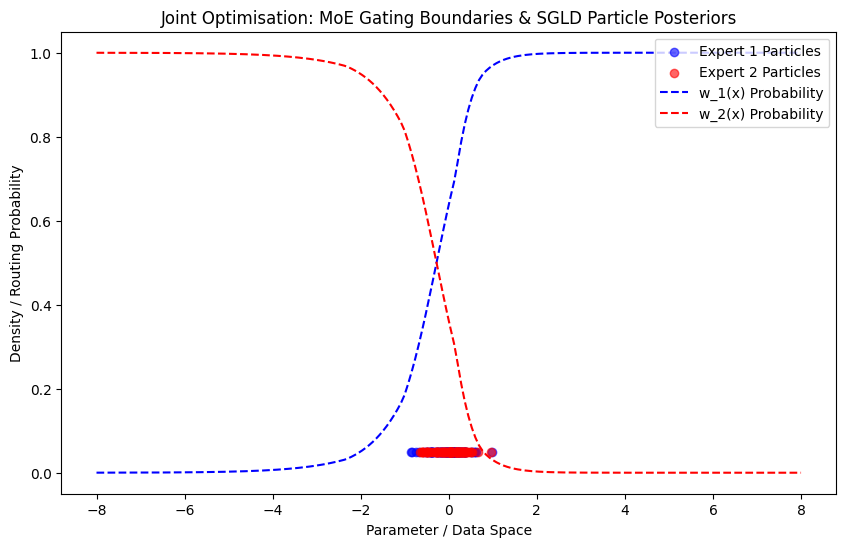

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. Toy Bimodal Data Setup ---
torch.manual_seed(42)
n_samples = 600
# Create distinct modes in the data space
X_data = torch.cat([
    torch.randn(n_samples // 2, 1) - 4.0,
    torch.randn(n_samples // 2, 1) + 4.0
])

# --- 2. Gating Network ---
class GatingNetwork(nn.Module):
    def __init__(self, input_dim=1, n_experts=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, n_experts),
            nn.Softmax(dim=1)
        )
    def forward(self, x):
        return self.net(x)

# --- 3. MMD Loss Function ---
def rbf_kernel(x, y, h=1.0):
    """
    Computes the RBF kernel. 
    Summing over dim=-1 removes the feature dimension, returning an (N, M) matrix.
    """
    dist = (x.unsqueeze(1) - y.unsqueeze(0)).pow(2).sum(dim=-1)
    return torch.exp(-dist / (2 * h**2))

def compute_moe_mmd_loss(X, W, particles_list, h=1.0):
    """Computes the squared MMD between True Data and MoE Predictive."""
    # True Data Intra-term
    term_XX = rbf_kernel(X, X, h).mean()
    
    # Cross term: True Data vs MoE
    term_X_MoE = 0
    for e, theta_e in enumerate(particles_list):
        K_X_theta = rbf_kernel(X, theta_e, h)
        # Weight by the gating probabilities
        weighted_K = W[:, e:e+1] * K_X_theta
        term_X_MoE += weighted_K.mean()
        
    # MoE Intra-term
    term_MoE_MoE = 0
    E = len(particles_list)
    for e, theta_e in enumerate(particles_list):
        for f, theta_f in enumerate(particles_list):
            K_theta_theta = rbf_kernel(theta_e, theta_f, h)
            # Assuming equal global routing prior \pi_e = 1/E
            term_MoE_MoE += K_theta_theta.mean() * (1.0 / (E**2))
            
    return term_XX - 2 * term_X_MoE + term_MoE_MoE

# --- 4. Joint Optimisation Setup ---
n_particles = 100
n_experts = 2
lr_particles = 0.05
lr_gate = 0.01
epochs = 500

# Initialise particles
theta_1 = torch.nn.Parameter(torch.randn(n_particles, 1) * 0.5)
theta_2 = torch.nn.Parameter(torch.randn(n_particles, 1) * 0.5)
particles = [theta_1, theta_2]

gate_net = GatingNetwork()
gate_optimizer = optim.Adam(gate_net.parameters(), lr=lr_gate)

# --- 5. Phase A & B Training Loop ---
for epoch in range(epochs):
    # ---------------------------------------------------------
    # PHASE A: Update Gating Network (Freezing the Particles)
    # ---------------------------------------------------------
    gate_optimizer.zero_grad()
    W = gate_net(X_data)
    
    # Detach particles so gradients only flow through the gate
    loss_gate = compute_moe_mmd_loss(X_data, W, [t.detach() for t in particles])
    loss_gate.backward()
    gate_optimizer.step()
    
    # ---------------------------------------------------------
    # PHASE B: Update Particles (SGLD-style via Autograd)
    # ---------------------------------------------------------
    W_detached = gate_net(X_data).detach()
    loss_particles = compute_moe_mmd_loss(X_data, W_detached, particles)
    loss_particles.backward()
    
    with torch.no_grad():
        for e, theta_e in enumerate(particles):
            # Prior Force (Assuming standard N(0, 10))
            prior_grad = -theta_e / 10.0
            
            # Autograd gives us the MMD descent direction for free
            drift = -theta_e.grad + prior_grad
            
            # SGLD Noise Injection
            noise = torch.sqrt(torch.tensor(2 * lr_particles)) * torch.randn_like(theta_e)
            theta_e.add_(lr_particles * drift + 0.1 * noise)
            
            # Zero out gradients for the next epoch
            theta_e.grad.zero_()

# --- 6. Plot the Posteriors & Decision Boundary ---
plt.figure(figsize=(10, 6))

# Plot SGLD Particle Posteriors
plt.scatter(theta_1.detach().numpy(), [0.05]*n_particles, color='blue', alpha=0.6, label='Expert 1 Particles')
plt.scatter(theta_2.detach().numpy(), [0.05]*n_particles, color='red', alpha=0.6, label='Expert 2 Particles')

# Plot the Gating Network's Decision Boundary
x_range = torch.linspace(-8, 8, 200).unsqueeze(1)
gate_probs = gate_net(x_range).detach()
plt.plot(x_range.numpy(), gate_probs[:, 0].numpy(), color='blue', linestyle='--', label='w_1(x) Probability')
plt.plot(x_range.numpy(), gate_probs[:, 1].numpy(), color='red', linestyle='--', label='w_2(x) Probability')

plt.title('Joint Optimisation: MoE Gating Boundaries & SGLD Particle Posteriors')
plt.xlabel('Parameter / Data Space')
plt.ylabel('Density / Routing Probability')
plt.legend(loc='upper right')
plt.show()

In [8]:
import torch
import torch.nn.functional as F

def execute_phase_3_math():
    print("--- Executing Phase 3 Mathematical Derivation ---")
    # Setup from Phase 3
    n = 2
    y = torch.tensor([[-1.0], [1.0]]) # y1 = -1, y2 = 1
    
    # phi(y) = y (Linear identity map for the signature)
    phi_y = y 
    
    # Preset router logits g(y) where router has already begun separating space
    # g_1(y_1) = 2, g_2(y_1) = -2  ||  g_1(y_2) = -2, g_2(y_2) = 2
    logits = torch.tensor([[2.0, -2.0],   # Data point 1 logits
                           [-2.0, 2.0]])  # Data point 2 logits

    def compute_flow(tau):
        print(f"\nEvaluating at Temperature tau = {tau}")
        
        # Equation 1: Temperature-Scaled Routing Logits
        pi = F.softmax(logits / tau, dim=1)
        print(f"Eq 1 (pi) for y1: [{pi[0, 0]:.4f}, {pi[0, 1]:.4f}]")
        print(f"Eq 1 (pi) for y2: [{pi[1, 0]:.4f}, {pi[1, 1]:.4f}]")
        
        # Equation 2: Expert Mass Normalisation
        rho = pi.sum(dim=0) / n
        print(f"Eq 2 (rho): [{rho[0]:.4f}, {rho[1]:.4f}]")
        
        # Equation 3: Finite-Feature Expert Signature
        # mu_e = (1 / n*rho_e) * sum(pi_e * phi(y))
        mu_1 = (pi[:, 0:1] * phi_y).sum(dim=0) / (n * rho[0])
        mu_2 = (pi[:, 1:2] * phi_y).sum(dim=0) / (n * rho[1])
        
        print(f"Eq 3 (mu_1 signature): {mu_1.item():.4f}")
        print(f"Eq 3 (mu_2 signature): {mu_2.item():.4f}")
        
        # Check computational sparsity threshold (< 1e-5)
        dense_computations = (pi > 1e-5).sum().item()
        print(f"Active data-expert computations: {dense_computations} out of {n * 2}")

    # Run Step 1 (Soft Phase)
    compute_flow(tau=1.0)
    
    # Run Step 2 (Hardening Phase)
    compute_flow(tau=0.1)

execute_phase_3_math()

--- Executing Phase 3 Mathematical Derivation ---

Evaluating at Temperature tau = 1.0
Eq 1 (pi) for y1: [0.9820, 0.0180]
Eq 1 (pi) for y2: [0.0180, 0.9820]
Eq 2 (rho): [0.5000, 0.5000]
Eq 3 (mu_1 signature): -0.9640
Eq 3 (mu_2 signature): 0.9640
Active data-expert computations: 4 out of 4

Evaluating at Temperature tau = 0.1
Eq 1 (pi) for y1: [1.0000, 0.0000]
Eq 1 (pi) for y2: [0.0000, 1.0000]
Eq 2 (rho): [0.5000, 0.5000]
Eq 3 (mu_1 signature): -1.0000
Eq 3 (mu_2 signature): 1.0000
Active data-expert computations: 2 out of 4


Epoch 000 | J(Loss): 2.8291 | Temp: 10.000
Epoch 100 | J(Loss): 1.4765 | Temp: 4.479
Epoch 200 | J(Loss): 0.0086 | Temp: 2.006
Epoch 300 | J(Loss): 0.0010 | Temp: 0.898
Epoch 400 | J(Loss): 0.0000 | Temp: 0.402
Epoch 500 | J(Loss): 0.0000 | Temp: 0.180


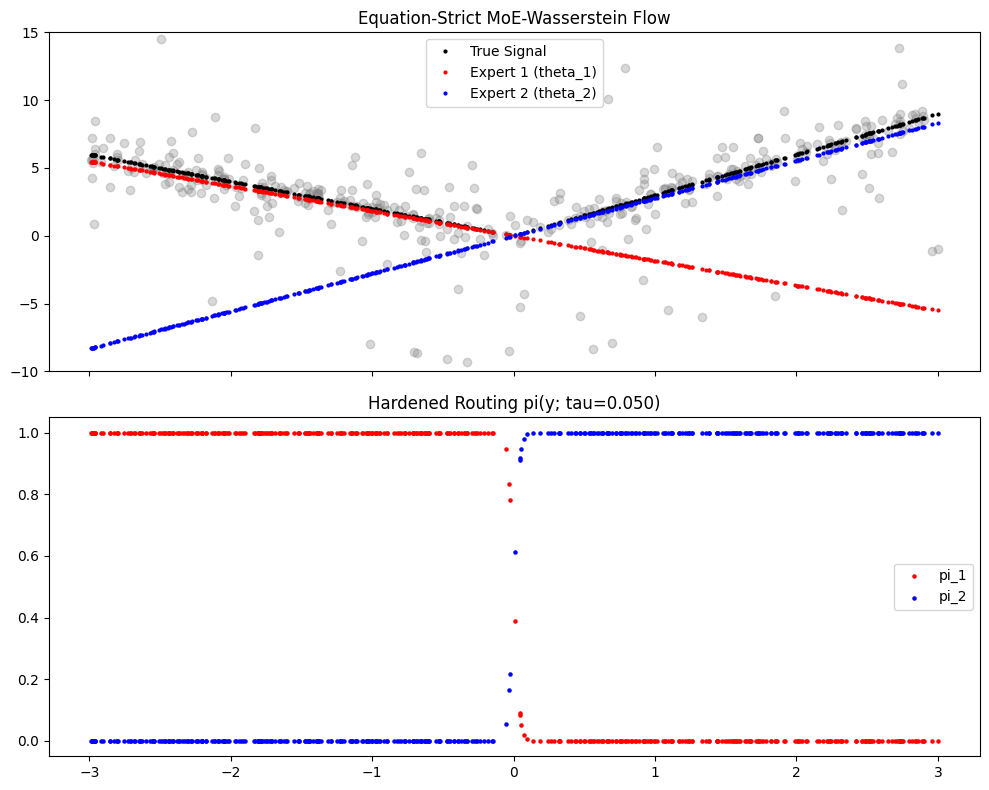

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class EquationStrictMoE(nn.Module):
    """
    A strict implementation of the mathematical MoE-Wasserstein flow.
    Variables exactly match the derived equations.
    """
    def __init__(self, input_dim, output_dim, num_experts):
        super().__init__()
        self.E = num_experts
        
        # W: Router weight matrix (Input -> Logits)
        self.W = nn.Parameter(torch.randn(input_dim, num_experts) * 0.1)
        
        # theta_e: Internal parameters for experts (Linear coefficients)
        self.theta = nn.Parameter(torch.randn(num_experts, input_dim, output_dim))
        
    def forward(self, x, y_target, tau):
        n = x.size(0)
        
        # --- EQUATION 1: Temperature-Scaled Routing Logits ---
        # g_e(y_i; W) = x @ W
        g = torch.matmul(x, self.W)
        pi = F.softmax(g / tau, dim=1) # Shape: [n, E]
        
        # --- EQUATION 2: Expert Mass Normalisation ---
        rho = pi.sum(dim=0) / n # Shape: [E]
        
        expert_signatures = []
        
        for e in range(self.E):
            # Extract weights for this specific expert e
            pi_e = pi[:, e:e+1] # Shape: [n, 1]
            
            # --- COMPUTATIONAL SPARSITY MASKING ---
            # Strictly enforces the O(n) collapse by ignoring zero-weight particles
            active_mask = pi_e > 1e-5
            
            if active_mask.any():
                active_x = x[active_mask.squeeze()]
                active_y = y_target[active_mask.squeeze()]
                active_pi = pi_e[active_mask.squeeze()]
                
                # phi(y_i; theta_e): The predictive embedding (Residual Error)
                # Prediction = active_x @ theta_e
                preds = torch.matmul(active_x, self.theta[e])
                phi = preds - active_y 
                
                # --- EQUATION 3: Finite-Feature Expert Signature ---
                # mu_e = (1 / n*rho_e) * sum(pi_e * phi)
                mu_e = (active_pi * phi).sum(dim=0) / (n * (rho[e] + 1e-9))
            else:
                mu_e = torch.zeros(y_target.size(1), device=x.device)
                
            expert_signatures.append(mu_e)
            
        stacked_mu = torch.stack(expert_signatures) # Shape: [E, output_dim]
        
        # --- EQUATION 4: Global Mean-Field Objective (Self-Energy) ---
        # J = 1/2 * || sum_e(rho_e * mu_e) ||^2
        # global_mu = (rho.unsqueeze(-1) * stacked_mu).sum(dim=0)
        # J = 0.5 * torch.sum(global_mu ** 2)
        J = 0.5 * torch.sum((rho ** 2) * torch.norm(stacked_mu, dim=1)**2)
        return J, pi, g

def train_strict_math_model():
    torch.manual_seed(42)
    
    # 1. Dual Data Generation (True: -2x for x<0, 3x for x>=0)
    n = 400
    x = torch.rand(n, 1) * 6 - 3
    y_true = torch.where(x < 0, -2 * x, 3 * x)
    
    # Cauchy noise misspecification
    noise = torch.clamp(torch.distributions.Cauchy(0, 0.5).sample((n, 1)), -10, 10)
    y_noisy = y_true + noise
    
    # 2. Initialise Model
    model = EquationStrictMoE(input_dim=1, output_dim=1, num_experts=2)
    
    # Bifurcated Optimisers (Router = Adam, Particles/Experts = SGD)
    opt_router = torch.optim.Adam([model.W], lr=0.01)
    opt_experts = torch.optim.SGD([model.theta], lr=0.1)
    
    epochs = 600
    tau_0 = 10.0
    tau_min = 0.05
    gamma = 0.992 # Slower annealing to prevent premature boundary lock-in
    
    for epoch in range(epochs):
        tau = max(tau_min, tau_0 * (gamma ** epoch))
        
        opt_router.zero_grad()
        opt_experts.zero_grad()
        
        # Forward pass executes Equations 1-4
        J, pi, _ = model(x, y_noisy, tau)
        
        J.backward()
        
        opt_router.step()
        opt_experts.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch:03d} | J(Loss): {J.item():.4f} | Temp: {tau:.3f}")

    # Visualise the result
    model.eval()
    with torch.no_grad():
        _, pi_final, _ = model(x, y_noisy, tau_min)
        
        # Generate predictions manually using learned theta
        pred_e1 = torch.matmul(x, model.theta[0])
        pred_e2 = torch.matmul(x, model.theta[1])
        
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    ax1.scatter(x.numpy(), y_noisy.numpy(), alpha=0.3, color='gray')
    ax1.plot(x.numpy(), y_true.numpy(), 'ko', markersize=2, label='True Signal')
    ax1.plot(x.numpy(), pred_e1.numpy(), 'ro', markersize=2, label='Expert 1 (theta_1)')
    ax1.plot(x.numpy(), pred_e2.numpy(), 'bo', markersize=2, label='Expert 2 (theta_2)')
    ax1.set_title('Equation-Strict MoE-Wasserstein Flow')
    ax1.set_ylim(-10, 15)
    ax1.legend()
    
    ax2.scatter(x.numpy(), pi_final[:, 0].numpy(), color='red', s=5, label='pi_1')
    ax2.scatter(x.numpy(), pi_final[:, 1].numpy(), color='blue', s=5, label='pi_2')
    ax2.set_title(f'Hardened Routing pi(y; tau={tau_min:.3f})')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_strict_math_model()

Training Bayesian Particle Flow...


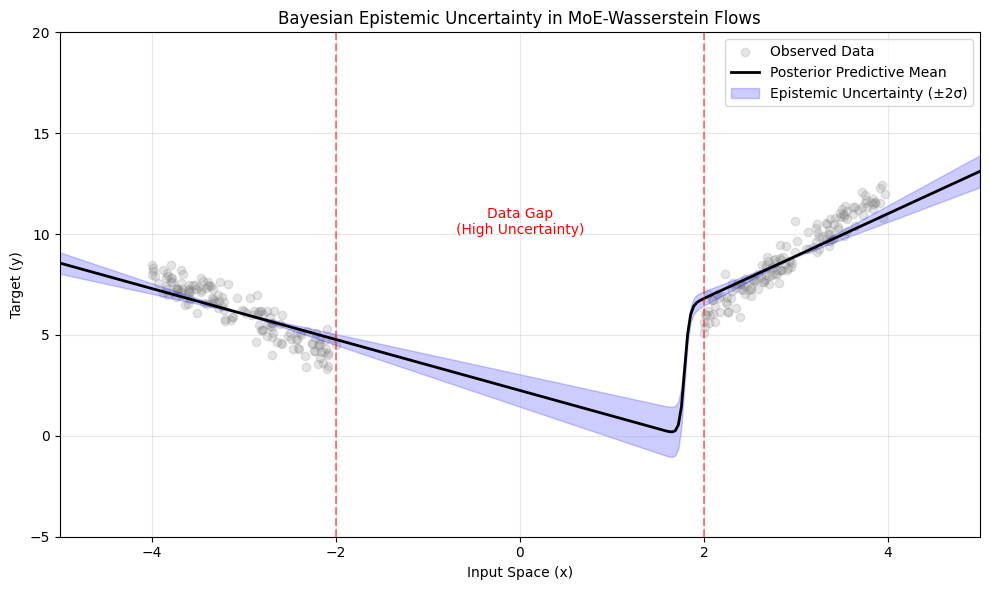

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class BayesianEquationStrictMoE(nn.Module):
    """
    An Annealed MoE-Wasserstein flow with Bayesian particle ensembles.
    Captures epistemic uncertainty via Randomised MAP Sampling and L2 Priors.
    """
    def __init__(self, input_dim, output_dim, num_experts, num_particles):
        super().__init__()
        self.E = num_experts
        self.K = num_particles
        
        # W: Router weight matrix (Input -> Logits)
        self.W = nn.Parameter(torch.randn(input_dim, num_experts) * 0.1)
        
        # theta: Ensemble of particles for each expert
        # Shape: [num_experts, num_particles, input_dim]
        self.theta = nn.Parameter(torch.randn(num_experts, num_particles, input_dim))
        
    def forward(self, x, y_target, tau, prior_lambda=0.1, noise_scale=0.5):
        n = x.size(0)
        
        # --- EQUATION 1 & 2: Routing and Normalisation ---
        g = torch.matmul(x, self.W)
        pi = F.softmax(g / tau, dim=1) 
        rho = pi.sum(dim=0) / n 
        
        J_data = 0.0
        
        for e in range(self.E):
            pi_e = pi[:, e:e+1] 
            active_mask = pi_e > 1e-5
            
            if active_mask.any():
                active_x = x[active_mask.squeeze()]
                active_y = y_target[active_mask.squeeze()]
                active_pi = pi_e[active_mask.squeeze()]
                n_active = active_x.size(0)
                
                # --- BAYESIAN MECHANIC: Particle Perturbation ---
                # Shape: [n_active, K, 1]
                preds = torch.matmul(active_x, self.theta[e].T).unsqueeze(-1)
                
                # Perturb the targets for each particle to prevent collapse
                noise = torch.randn(n_active, self.K, 1, device=x.device) * noise_scale
                perturbed_y = active_y.unsqueeze(1) + noise
                
                # phi: The predictive residual for all K particles
                phi = preds - perturbed_y
                
                # --- EQUATION 3: Finite-Feature Expert Signatures ---
                # mu_ek = (1 / n*rho_e) * sum(pi_e * phi_k)
                # We calculate a separate signature for every particle in the ensemble
                active_pi_expanded = active_pi.unsqueeze(-1)
                mu_ek = (active_pi_expanded * phi).sum(dim=0) / (n * (rho[e] + 1e-9))
                
                # --- STRICT GRAM MATRIX SPARSITY ---
                # Norm applied BEFORE summing across experts to prevent cancellation
                J_data += 0.5 * (rho[e] ** 2) * torch.sum(torch.norm(mu_ek, dim=1)**2)
                
        # --- BAYESIAN MECHANIC: The L2 Prior ---
        # Pulls particles towards the origin in regions without data
        J_prior = prior_lambda * torch.sum(self.theta ** 2)
        
        J_total = J_data + J_prior
        return J_total, pi
    


def train_and_visualise_bayesian_gap():
    torch.manual_seed(42)
    
    # 1. The Epistemic Data Gap Dataset
    # Data only exists on the far left and far right. A massive gap exists in the middle.
    n_cluster = 150
    x_left = torch.rand(n_cluster, 1) * 2 - 4   # [-4, -2]
    x_right = torch.rand(n_cluster, 1) * 2 + 2  # [2, 4]
    x = torch.cat([x_left, x_right])
    
    # Add a bias column of 1s for the linear intercept
    x_aug = torch.cat([x, torch.ones_like(x)], dim=1)
    
    y_true = torch.where(x < 0, -2 * x, 3 * x)
    y_noisy = y_true + torch.randn_like(y_true) * 0.5
    
    # 2. Initialise Bayesian Model (20 particles per expert)
    num_particles = 20
    model = BayesianEquationStrictMoE(input_dim=2, output_dim=1, num_experts=2, num_particles=num_particles)
    
    opt_router = torch.optim.Adam([model.W], lr=0.01)
    opt_experts = torch.optim.SGD([model.theta], lr=0.05)
    
    epochs = 600
    tau_0 = 10.0
    tau_min = 0.05
    gamma = 0.99 
    
    print("Training Bayesian Particle Flow...")
    for epoch in range(epochs):
        tau = max(tau_min, tau_0 * (gamma ** epoch))
        
        opt_router.zero_grad()
        opt_experts.zero_grad()
        
        J, pi = model(x_aug, y_noisy, tau, prior_lambda=0.01, noise_scale=0.5)
        J.backward()
        
        opt_router.step()
        opt_experts.step()

    # 3. Visualising the Epistemic Uncertainty
    model.eval()
    
    # Generate test points spanning the entire domain, including the gap
    x_test = torch.linspace(-5, 5, 300).unsqueeze(1)
    x_test_aug = torch.cat([x_test, torch.ones_like(x_test)], dim=1)
    
    with torch.no_grad():
        _, pi_test = model(x_test_aug, torch.zeros_like(x_test), tau_min)
        
        # Calculate predictions for ALL particles across both experts
        preds_e1 = torch.matmul(x_test_aug, model.theta[0].T) # [300, 20]
        preds_e2 = torch.matmul(x_test_aug, model.theta[1].T) # [300, 20]
        
        # Route the predictions (Model Averaging)
        pi_1 = pi_test[:, 0:1]
        pi_2 = pi_test[:, 1:2]
        
        # The final ensemble prediction is a weighted sum of the active experts
        ensemble_preds = pi_1 * preds_e1 + pi_2 * preds_e2
        
        # Calculate Bayesian Mean and Standard Deviation
        y_mean = ensemble_preds.mean(dim=1)
        y_std = ensemble_preds.std(dim=1)
        
    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot the raw data
    plt.scatter(x.numpy(), y_noisy.numpy(), alpha=0.2, color='gray', label='Observed Data')
    
    # Plot the Bayesian Mean
    plt.plot(x_test.numpy(), y_mean.numpy(), 'k-', linewidth=2, label='Posterior Predictive Mean')
    
    # Plot the Epistemic Uncertainty (± 2 Standard Deviations)
    plt.fill_between(x_test.squeeze().numpy(), 
                     (y_mean - 2*y_std).numpy(), 
                     (y_mean + 2*y_std).numpy(), 
                     color='blue', alpha=0.2, label='Epistemic Uncertainty (±2σ)')
    
    # Annotate the gap
    plt.axvline(x=-2, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=2, color='red', linestyle='--', alpha=0.5)
    plt.text(0, 10, 'Data Gap\n(High Uncertainty)', horizontalalignment='center', color='red')
    
    plt.title('Bayesian Epistemic Uncertainty in MoE-Wasserstein Flows')
    plt.xlabel('Input Space (x)')
    plt.ylabel('Target (y)')
    plt.xlim(-5, 5)
    plt.ylim(-5, 20)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_and_visualise_bayesian_gap()

Training Balanced SGLD Flow...


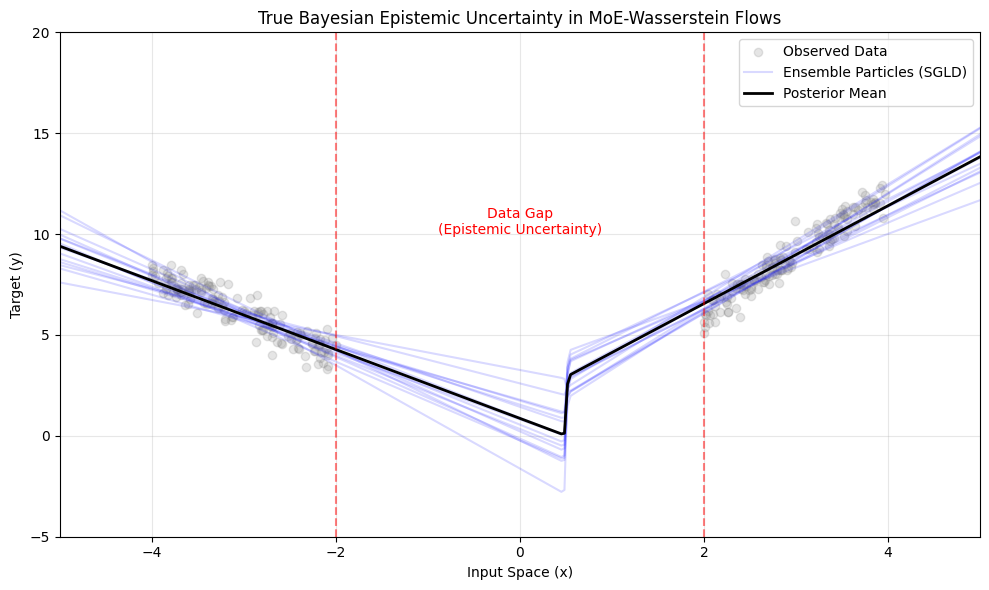

In [19]:
def run_true_bayesian_sgld():
    torch.manual_seed(42)
    
    # 1. Dataset Generation
    n_cluster = 150
    x_left = torch.rand(n_cluster, 1) * 2 - 4   
    x_right = torch.rand(n_cluster, 1) * 2 + 2  
    x = torch.cat([x_left, x_right])
    x_aug = torch.cat([x, torch.ones_like(x)], dim=1)
    
    y_true = torch.where(x < 0, -2 * x, 3 * x)
    y_noisy = y_true + torch.randn_like(y_true) * 0.5
    
    model = BayesianEquationStrictMoE(input_dim=2, output_dim=1, num_experts=2, num_particles=15)
    
    # THE GOLDILOCKS PARAMETERS
    # Fast enough to find the split, light enough decay to not kill the weights
    opt_router = torch.optim.Adam([model.W], lr=0.05, weight_decay=1e-4)
    
    lr_experts = 0.01
    langevin_temp = 0.02 # Warm enough to fan out, cool enough to stick to the data
    
    epochs = 600
    tau_0 = 10.0
    tau_min = 0.05
    gamma = 0.99 
    
    print("Training Balanced SGLD Flow...")
    for epoch in range(epochs):
        tau = max(tau_min, tau_0 * (gamma ** epoch))
        
        opt_router.zero_grad()
        if model.theta.grad is not None:
            model.theta.grad.zero_()
        
        # Moderate prior and target perturbation
        J, pi = model(x_aug, y_noisy, tau, prior_lambda=0.01, noise_scale=0.2)
        J.backward()
        
        opt_router.step()
        
        with torch.no_grad():
            model.theta.data -= lr_experts * model.theta.grad
            
            # The calibrated thermal noise
            noise_scale = torch.sqrt(torch.tensor(2.0 * lr_experts * langevin_temp))
            langevin_noise = torch.randn_like(model.theta.data) * noise_scale
            model.theta.data += langevin_noise

    # Visualisation
    model.eval()
    x_test = torch.linspace(-5, 5, 300).unsqueeze(1)
    x_test_aug = torch.cat([x_test, torch.ones_like(x_test)], dim=1)
    
    with torch.no_grad():
        _, pi_test = model(x_test_aug, torch.zeros_like(x_test), tau_min)
        
        preds_e1 = torch.matmul(x_test_aug, model.theta[0].T)
        preds_e2 = torch.matmul(x_test_aug, model.theta[1].T)
        
        pi_1 = pi_test[:, 0:1]
        pi_2 = pi_test[:, 1:2]
        
        ensemble_preds = pi_1 * preds_e1 + pi_2 * preds_e2
        y_mean = ensemble_preds.mean(dim=1)
        
    plt.figure(figsize=(10, 6))
    plt.scatter(x.numpy(), y_noisy.numpy(), alpha=0.2, color='gray', label='Observed Data')
    
    for k in range(ensemble_preds.size(1)):
        label = 'Ensemble Particles (SGLD)' if k == 0 else None
        plt.plot(x_test.numpy(), ensemble_preds[:, k].numpy(), color='blue', alpha=0.15, label=label)
        
    plt.plot(x_test.numpy(), y_mean.numpy(), 'k-', linewidth=2, label='Posterior Mean')
    
    plt.axvline(x=-2, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=2, color='red', linestyle='--', alpha=0.5)
    plt.text(0, 10, 'Data Gap\n(Epistemic Uncertainty)', horizontalalignment='center', color='red')
    
    plt.title('True Bayesian Epistemic Uncertainty in MoE-Wasserstein Flows')
    plt.xlabel('Input Space (x)')
    plt.ylabel('Target (y)')
    plt.xlim(-5, 5)
    plt.ylim(-5, 20)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_true_bayesian_sgld()

Training Model A: GM-PVI Equivalent (Plug-in MoE with Point Collapse)...
Training Model B: Our Method (Annealed SGLD Particle Flow)...


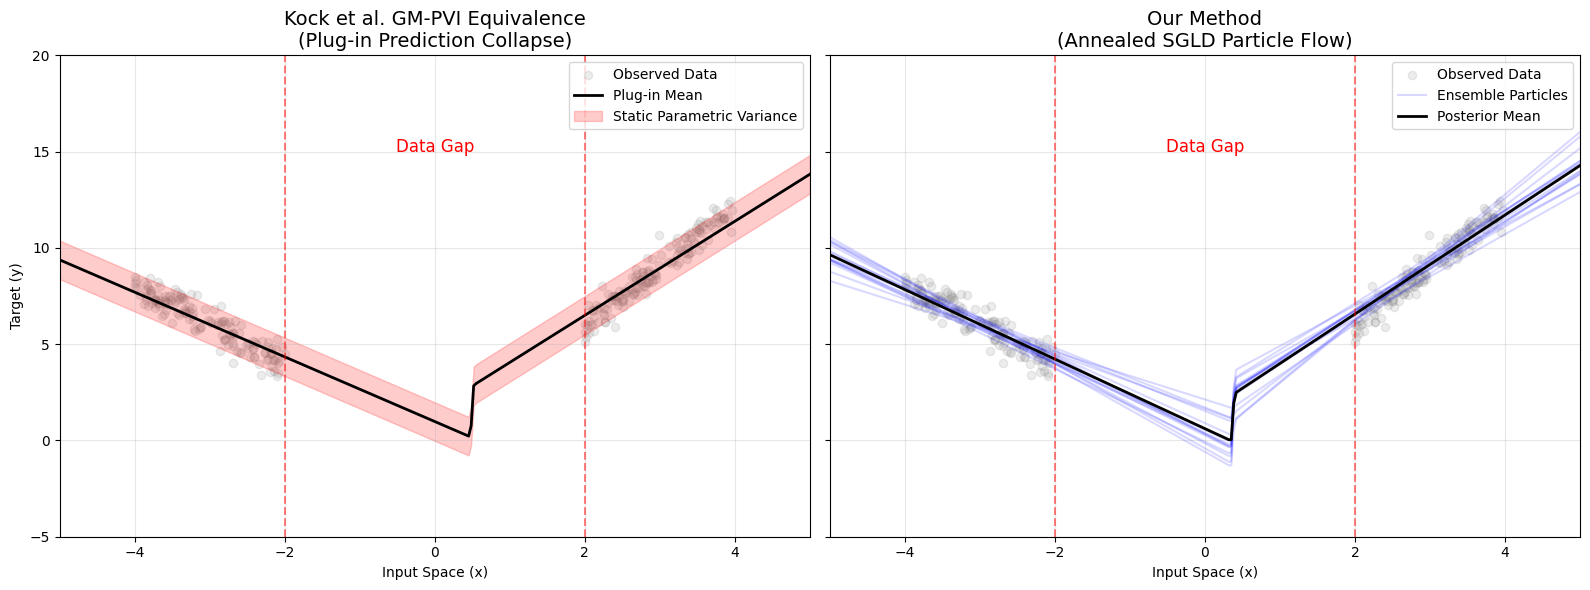

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# =============================================================================
# 1. The Core Architecture (Shared by both models)
# =============================================================================
class ParticleMoE(nn.Module):
    """
    A unified architecture that can act as either a Plug-in GM-PVI MoE 
    (if trained with standard SGD) or a True Bayesian MoE (if trained with SGLD).
    """
    def __init__(self, input_dim, output_dim, num_experts, num_particles):
        super().__init__()
        self.E = num_experts
        self.K = num_particles
        
        # Router weights
        self.W = nn.Parameter(torch.randn(input_dim, num_experts) * 0.1)
        # Particle ensemble for experts
        self.theta = nn.Parameter(torch.randn(num_experts, num_particles, input_dim))
        
    def forward(self, x, y_target, tau, prior_lambda=0.01, noise_scale=0.2):
        n = x.size(0)
        
        # Routing and Normalisation
        g = torch.matmul(x, self.W)
        pi = F.softmax(g / tau, dim=1) 
        rho = pi.sum(dim=0) / n 
        
        J_data = 0.0
        
        for e in range(self.E):
            pi_e = pi[:, e:e+1] 
            active_mask = pi_e > 1e-5
            
            if active_mask.any():
                active_x = x[active_mask.squeeze()]
                active_y = y_target[active_mask.squeeze()]
                active_pi = pi_e[active_mask.squeeze()]
                n_active = active_x.size(0)
                
                # Predictions and perturbation
                preds = torch.matmul(active_x, self.theta[e].T).unsqueeze(-1)
                noise = torch.randn(n_active, self.K, 1, device=x.device) * noise_scale
                phi = preds - (active_y.unsqueeze(1) + noise)
                
                # Expert Signatures & Gram Matrix Sparsity
                active_pi_expanded = active_pi.unsqueeze(-1)
                mu_ek = (active_pi_expanded * phi).sum(dim=0) / (n * (rho[e] + 1e-9))
                J_data += 0.5 * (rho[e] ** 2) * torch.sum(torch.norm(mu_ek, dim=1)**2)
                
        # L2 Prior
        J_prior = prior_lambda * torch.sum(self.theta ** 2)
        return J_data + J_prior, pi

# =============================================================================
# 2. The Training Loop (Configurable for SGD vs SGLD)
# =============================================================================
def train_model(model, x, y, epochs=600, use_sgld=False):
    """
    Trains the model. If use_sgld=False, the particles collapse to a point 
    estimate (mimicking the GM-PVI Plug-in). If True, they form a true posterior.
    """
    # Router optimiser uses slight weight decay to centre the gap boundary
    opt_router = torch.optim.Adam([model.W], lr=0.05, weight_decay=1e-4)
    lr_experts = 0.01
    
    # Goldilocks temperature for SGLD, 0.0 for standard deterministic SGD
    langevin_temp = 0.02 if use_sgld else 0.0 
    
    tau_0 = 10.0
    tau_min = 0.05
    gamma = 0.99 
    
    for epoch in range(epochs):
        tau = max(tau_min, tau_0 * (gamma ** epoch))
        
        opt_router.zero_grad()
        if model.theta.grad is not None:
            model.theta.grad.zero_()
        
        J, _ = model(x, y, tau)
        J.backward()
        opt_router.step()
        
        with torch.no_grad():
            # Standard gradient descent
            model.theta.data -= lr_experts * model.theta.grad
            
            # SGLD Thermal Noise Injection (Only active if use_sgld=True)
            if use_sgld:
                noise_scale = torch.sqrt(torch.tensor(2.0 * lr_experts * langevin_temp))
                langevin_noise = torch.randn_like(model.theta.data) * noise_scale
                model.theta.data += langevin_noise
                
    return model

# =============================================================================
# 3. Experiment Execution and Dual Visualisation
# =============================================================================
def run_paper_comparison():
    torch.manual_seed(42)
    
    # 1. Dataset Generation (The Epistemic Gap)
    n_cluster = 150
    x_left = torch.rand(n_cluster, 1) * 2 - 4   
    x_right = torch.rand(n_cluster, 1) * 2 + 2  
    x = torch.cat([x_left, x_right])
    x_aug = torch.cat([x, torch.ones_like(x)], dim=1) # Add bias term
    
    y_true = torch.where(x < 0, -2 * x, 3 * x)
    y_noisy = y_true + torch.randn_like(y_true) * 0.5
    
    # 2. Initialise and Train Both Models
    print("Training Model A: GM-PVI Equivalent (Plug-in MoE with Point Collapse)...")
    model_plugin = ParticleMoE(input_dim=2, output_dim=1, num_experts=2, num_particles=15)
    model_plugin = train_model(model_plugin, x_aug, y_noisy, use_sgld=False)
    
    print("Training Model B: Our Method (Annealed SGLD Particle Flow)...")
    model_sgld = ParticleMoE(input_dim=2, output_dim=1, num_experts=2, num_particles=15)
    model_sgld = train_model(model_sgld, x_aug, y_noisy, use_sgld=True)
    
    # 3. Inference and Plotting Setup
    x_test = torch.linspace(-5, 5, 300).unsqueeze(1)
    x_test_aug = torch.cat([x_test, torch.ones_like(x_test)], dim=1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # Helper function to generate and plot predictions
    def evaluate_and_plot(model, ax, title, is_plugin):
        model.eval()
        with torch.no_grad():
            _, pi_test = model(x_test_aug, torch.zeros_like(x_test), tau=0.05)
            preds_e1 = torch.matmul(x_test_aug, model.theta[0].T)
            preds_e2 = torch.matmul(x_test_aug, model.theta[1].T)
            
            ensemble_preds = pi_test[:, 0:1] * preds_e1 + pi_test[:, 1:2] * preds_e2
            y_mean = ensemble_preds.mean(dim=1)
            
        ax.scatter(x.numpy(), y_noisy.numpy(), alpha=0.15, color='gray', label='Observed Data')
        
        if is_plugin:
            # GM-PVI Plug-in uses a static parametric variance (e.g., constant observational noise)
            static_std = 0.5 
            ax.plot(x_test.numpy(), y_mean.numpy(), 'k-', linewidth=2, label='Plug-in Mean')
            ax.fill_between(x_test.squeeze().numpy(), 
                            (y_mean - 2*static_std).numpy(), 
                            (y_mean + 2*static_std).numpy(), 
                            color='red', alpha=0.2, label='Static Parametric Variance')
        else:
            # Our SGLD Method explicitly renders the fanned-out particles
            for k in range(ensemble_preds.size(1)):
                label = 'Ensemble Particles' if k == 0 else None
                ax.plot(x_test.numpy(), ensemble_preds[:, k].numpy(), color='blue', alpha=0.15, label=label)
            ax.plot(x_test.numpy(), y_mean.numpy(), 'k-', linewidth=2, label='Posterior Mean')
            
        # Draw Data Gap boundaries
        ax.axvline(x=-2, color='red', linestyle='--', alpha=0.5)
        ax.axvline(x=2, color='red', linestyle='--', alpha=0.5)
        ax.text(0, 15, 'Data Gap', horizontalalignment='center', color='red', fontsize=12)
        
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Input Space (x)')
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 20)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')

    # Execute plotting
    evaluate_and_plot(model_plugin, ax1, 'Kock et al. GM-PVI Equivalence\n(Plug-in Prediction Collapse)', is_plugin=True)
    evaluate_and_plot(model_sgld, ax2, 'Our Method\n(Annealed SGLD Particle Flow)', is_plugin=False)
    
    ax1.set_ylabel('Target (y)')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_paper_comparison()

In [21]:
"""
mmd_pro_toy.py
==============
A minimal, *fully analytically verifiable* reference for the MMD-PrO posterior
(Shen et al. 2025 PCUQ; McLatchie et al. 2025), in 1-D, built so that EVERY line
can be justified and checked.

Why this particular toy:
  - Model is a location family  P_theta = N(theta, sigma^2)  (sigma known).
  - With a Gaussian kernel, the MMD^2 between the mixture predictive
        P_Q = (1/N) sum_j N(theta_j, sigma^2)
    and the empirical data measure  Phat_n = (1/n) sum_i delta_{y_i}
    is CLOSED FORM in the particle locations theta_j.  => analytic gradient,
    no inner Monte-Carlo, so we can check the force exactly.
  - The PrO posterior Q over theta is carried by particles theta_1..theta_N and
    evolved by overdamped Langevin / mean-field Langevin (MFLD), which is the
    engine the PCUQ paper actually uses (it uses MALA, the MH-corrected version).

The script runs four checks and prints PASS/FAIL with numbers:
  V1  objective + analytic-gradient agree with JAX autodiff (machine precision).
  V1b deterministic flow (tau=0) makes MMD^2 monotonically decrease (drift sign).
  V2  for N=1 the EM-Langevin sampler reproduces the *known* stationary density
        pi(theta) ∝ exp(-U(theta)/tau),  U = MMD^2_{N=1}.   <-- discretization check
  V3  Adam on the SAME objective does NOT sample pi: deterministic Adam collapses
        to argmin U (a MAP point, zero spread), and Adam+noise gives the WRONG
        spread, because Adam's per-coordinate v_t rescales drift AND noise.
Finally it shows the qualitative PrO behaviour: under a misspecified (bimodal)
data set the unimodal Gaussian model is lifted to a bimodal predictive.
"""

import numpy as np
import matplotlib
matplotlib.use("Agg")  # headless backend; we only save a PNG, never show a window
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)  # float64: autodiff check must be to ~1e-12,
                                            # float32 would only agree to ~1e-4 and muddy V1
import jax.numpy as jnp

rng = np.random.default_rng(0)  # single seed -> fully reproducible run


# ----------------------------------------------------------------------------- #
# Section 0.  Problem configuration.  Every constant is justified inline.
# ----------------------------------------------------------------------------- #
d        = 1        # ambient dimension. Start at 1 so we can plot the density exactly.
sigma    = 0.5      # KNOWN model noise sd. Model is N(theta, sigma^2 I_d).
n_data   = 200      # number of observations y_i.

# Two data-generating regimes.
mu_star  = 0.0                       # well-specified truth: y ~ N(mu_star, sigma^2)
mode_sep = 2.0                       # misspecified truth: 1/2 N(-2,s0^2)+1/2 N(+2,s0^2)
s0       = 0.4                       # sd of each true mode (model cannot represent 2 modes)

y_well = rng.normal(mu_star, sigma, size=(n_data, d))                 # well-specified data
comp   = rng.integers(0, 2, size=n_data)                             # which mode each point is from
centers= np.where(comp == 0, -mode_sep, +mode_sep).astype(float)[:, None]
y_mis  = rng.normal(0.0, s0, size=(n_data, d)) + centers             # misspecified (bimodal) data

# Kernel bandwidth ell via the MEDIAN HEURISTIC on the data (the standard default).
# Rationale: sets ell to the typical pairwise scale so the kernel neither saturates
# (ell too big -> k≈1 everywhere -> no discrimination) nor sees only self-pairs
# (ell too small -> k≈0 off-diagonal). We compute it on whichever data we score.
def median_heuristic(y):
    # pairwise Euclidean distances among data points, take the median of the
    # strictly-upper-triangular part (exclude the zero self-distances).
    D = np.sqrt(((y[:, None, :] - y[None, :, :]) ** 2).sum(-1))
    iu = np.triu_indices(len(y), k=1)
    return np.median(D[iu])

ell_well = median_heuristic(y_well)
ell_mis  = median_heuristic(y_mis)

tau = 0.02   # ENTROPY-REGULARISATION temperature. Langevin stationary law is
             # pi ∝ exp(-U/tau); larger tau => wider posterior. The V2 check holds
             # for ANY tau, so this choice is not load-bearing for correctness.
h   = 5e-3   # Langevin step size. Must satisfy h * L < ~1 for EM stability, where
             # L is the gradient-Lipschitz constant (~curvature of U). 5e-3 is well
             # inside stability here and keeps the O(h) EM discretisation bias small.


# ----------------------------------------------------------------------------- #
# Section 1.  Closed-form MMD^2(theta) and its ANALYTIC gradient.
#
# Gaussian kernel k(x,x') = exp(-||x-x'||^2 / (2 ell^2)).
# For X~N(a, s^2 I_d), X'~N(b, t^2 I_d):
#     E[k(X,X')] = (ell^2/(ell^2+s^2+t^2))^{d/2} * exp(-||a-b||^2 / (2(ell^2+s^2+t^2)))
# Apply with:
#   model-model:  a=theta_j, b=theta_{j'}, s=t=sigma  -> width s2^2 = ell^2 + 2 sigma^2
#   model-data:   a=theta_j, b=y_i (point, t=0), s=sigma -> width s1^2 = ell^2 + sigma^2
#   data-data:    constant in theta -> dropped from the gradient (kept for the value).
# ----------------------------------------------------------------------------- #
def mmd_constants(ell):
    s1_sq = ell**2 + sigma**2          # model-data Gaussian width
    s2_sq = ell**2 + 2.0 * sigma**2    # model-model Gaussian width
    c1    = (ell**2 / s1_sq) ** (d / 2.0)   # model-data amplitude
    c2    = (ell**2 / s2_sq) ** (d / 2.0)   # model-model amplitude
    return s1_sq, s2_sq, c1, c2

def mmd2_np(theta, y, ell):
    """Closed-form MMD^2(P_Q, Phat_n). theta:(N,d), y:(n,d). Returns scalar."""
    N = theta.shape[0]; n = y.shape[0]
    s1_sq, s2_sq, c1, c2 = mmd_constants(ell)
    # squared pairwise distances
    dd_tt = ((theta[:, None, :] - theta[None, :, :]) ** 2).sum(-1)   # (N,N) particle-particle
    dd_ty = ((theta[:, None, :] - y[None, :, :])     ** 2).sum(-1)   # (N,n) particle-data
    dd_yy = ((y[:, None, :]     - y[None, :, :])     ** 2).sum(-1)   # (n,n) data-data
    term_mm =  c2 * np.exp(-dd_tt / (2 * s2_sq))                      # model-model kernel matrix
    term_md =  c1 * np.exp(-dd_ty / (2 * s1_sq))                      # model-data  kernel matrix
    term_dd =       np.exp(-dd_yy / (2 * ell**2))                     # data-data   kernel matrix
    mm = term_mm.mean()                                              # (1/N^2) sum
    md = term_md.mean()                                              # (1/(N n)) sum
    dd = term_dd.mean()                                              # (1/n^2) sum
    return mm - 2.0 * md + dd                                        # MMD^2 = ||mu_PQ - mu_Phat||^2

def grad_mmd2_np(theta, y, ell):
    """Analytic gradient wrt theta of mmd2_np. Returns (N,d).
       Derivation (per particle j):
         d/dtheta_j [ (1/N^2) sum_{a,b} A_{ab} ] = (2/N^2) sum_{j'} A_{jj'} * dA-arg
           with A_{jj'} = c2 exp(-||t_j-t_j'||^2/(2 s2^2)),
           giving  - (2/(N^2 s2^2)) sum_{j'} A_{jj'} (theta_j - theta_{j'})   [REPULSION]
         d/dtheta_j [ -(2/(N n)) sum_{j,i} B_{ji} ]
           with B_{ji} = c1 exp(-||t_j-y_i||^2/(2 s1^2)),
           giving  + (2/(N n s1^2)) sum_i B_{ji} (theta_j - y_i)              [DATA ATTRACTION]
       (data-data term is constant in theta -> no contribution.)
    """
    N = theta.shape[0]; n = y.shape[0]
    s1_sq, s2_sq, c1, c2 = mmd_constants(ell)
    diff_tt = theta[:, None, :] - theta[None, :, :]                  # (N,N,d)
    diff_ty = theta[:, None, :] - y[None, :, :]                      # (N,n,d)
    A = c2 * np.exp(-(diff_tt**2).sum(-1) / (2 * s2_sq))             # (N,N)
    B = c1 * np.exp(-(diff_ty**2).sum(-1) / (2 * s1_sq))            # (N,n)
    grad_mm = -(2.0 / (N**2 * s2_sq)) * (A[:, :, None] * diff_tt).sum(1)   # (N,d) repulsion
    grad_md =  (2.0 / (N * n * s1_sq)) * (B[:, :, None] * diff_ty).sum(1)  # (N,d) attraction
    return grad_mm + grad_md

# Independent JAX transcription of the SAME objective, used only as an autodiff oracle.
def mmd2_jax(theta, y, ell):
    s1_sq = ell**2 + sigma**2
    s2_sq = ell**2 + 2.0 * sigma**2
    c1 = (ell**2 / s1_sq) ** (d / 2.0)
    c2 = (ell**2 / s2_sq) ** (d / 2.0)
    dd_tt = ((theta[:, None, :] - theta[None, :, :]) ** 2).sum(-1)
    dd_ty = ((theta[:, None, :] - y[None, :, :])     ** 2).sum(-1)
    dd_yy = ((y[:, None, :]     - y[None, :, :])     ** 2).sum(-1)
    mm = (c2 * jnp.exp(-dd_tt / (2 * s2_sq))).mean()
    md = (c1 * jnp.exp(-dd_ty / (2 * s1_sq))).mean()
    dd = (jnp.exp(-dd_yy / (2 * ell**2))).mean()
    return mm - 2.0 * md + dd

grad_mmd2_jax = jax.grad(mmd2_jax, argnums=0)


# ----------------------------------------------------------------------------- #
# V1.  Objective + analytic gradient vs JAX autodiff (machine-precision check).
# ----------------------------------------------------------------------------- #
print("=" * 70)
print("V1  objective & gradient correctness (analytic vs autodiff)")
theta_test = rng.normal(0, 1.5, size=(7, d))     # arbitrary particle config
ell_test   = 0.9
val_np  = mmd2_np(theta_test, y_mis, ell_test)
val_jax = float(mmd2_jax(jnp.asarray(theta_test), jnp.asarray(y_mis), ell_test))
g_np    = grad_mmd2_np(theta_test, y_mis, ell_test)
g_jax   = np.asarray(grad_mmd2_jax(jnp.asarray(theta_test), jnp.asarray(y_mis), ell_test))
obj_err  = abs(val_np - val_jax)
grad_err = np.abs(g_np - g_jax).max()
print(f"    |obj_np - obj_jax|        = {obj_err:.2e}   (expect < 1e-10)")
print(f"    max|grad_np - grad_jax|   = {grad_err:.2e}   (expect < 1e-8)")
print(f"    V1 {'PASS' if (obj_err < 1e-10 and grad_err < 1e-8) else 'FAIL'}")


# ----------------------------------------------------------------------------- #
# V1b.  Deterministic flow (tau=0): MMD^2 must DECREASE monotonically.
#       This checks the SIGN/scale of the drift for the full N-particle force.
# ----------------------------------------------------------------------------- #
print("=" * 70)
print("V1b deterministic flow decreases MMD^2 (drift is a descent direction)")
th = rng.normal(0, 2.0, size=(40, d))
traj = [mmd2_np(th, y_mis, ell_mis)]
for _ in range(400):
    th = th - h * grad_mmd2_np(th, y_mis, ell_mis)   # gradient DESCENT step, no noise
    traj.append(mmd2_np(th, y_mis, ell_mis))
traj = np.array(traj)
increases = np.sum(np.diff(traj) > 1e-12)            # count steps that went UP
print(f"    start MMD^2={traj[0]:.5f}  end MMD^2={traj[-1]:.5f}  steps_increasing={increases}")
print(f"    V1b {'PASS' if increases == 0 and traj[-1] < traj[0] else 'FAIL'}")


# ----------------------------------------------------------------------------- #
# Section 2.  Single-particle (N=1) potential and the three updaters.
#
# For N=1 the model-model term is the constant c2 (self pair), so
#     U(theta) = c2 - (2 c1 / n) sum_i exp(-||theta - y_i||^2 / (2 s1^2)) + const
# Its gradient is just the data-attraction term. We run M independent N=1 chains
# in parallel; their final states are ~iid samples from the sampler's stationary law.
# ----------------------------------------------------------------------------- #
def U_single(theta_scalar, y, ell):
    """Potential U(theta) for the N=1 system, vectorised over a grid/batch of theta.
       theta_scalar: (...,) array of 1-D locations. Returns same shape."""
    s1_sq, _, c1, c2 = mmd_constants(ell)
    yy = y[:, 0]                                            # (n,)
    # exp term summed over data, broadcast over the batch dimension
    e  = np.exp(-(theta_scalar[..., None] - yy) ** 2 / (2 * s1_sq)).sum(-1)
    return c2 - (2.0 * c1 / len(y)) * e                    # (drop the +const; irrelevant to pi)

def gradU_single(theta_batch, y, ell):
    """d U/d theta for a batch of independent N=1 chains. theta_batch:(M,1)."""
    s1_sq, _, c1, c2 = mmd_constants(ell)
    diff = theta_batch[:, 0][:, None] - y[:, 0][None, :]    # (M,n)
    B    = c1 * np.exp(-diff**2 / (2 * s1_sq))             # (M,n)
    g    = (2.0 / (len(y) * s1_sq)) * (B * diff).sum(1)    # (M,) attraction-only gradient
    return g[:, None]                                      # (M,1)

M, T = 20000, 2000          # M independent chains, T steps each (final state = 1 sample)
y, ell = y_mis, ell_mis     # use the bimodal data: U is bimodal -> a sharp test

# (A) Correct Euler-Maruyama Langevin:  theta -= h*gradU ; theta += sqrt(2 h tau)*xi
th_lan = rng.normal(0, 2.5, size=(M, 1))
for _ in range(T):
    th_lan = th_lan - h * gradU_single(th_lan, y, ell)
    th_lan = th_lan + np.sqrt(2 * h * tau) * rng.normal(size=(M, 1))

# (B) Adam, DETERMINISTIC (what "just minimise the objective" does). Standard hypers.
lr, b1, b2, eps = 1e-2, 0.9, 0.999, 1e-8
th_adam = rng.normal(0, 2.5, size=(M, 1)); m_=np.zeros_like(th_adam); v_=np.zeros_like(th_adam)
for t in range(1, T + 1):
    g  = gradU_single(th_adam, y, ell)
    m_ = b1 * m_ + (1 - b1) * g
    v_ = b2 * v_ + (1 - b2) * g * g
    mh = m_ / (1 - b1**t); vh = v_ / (1 - b2**t)
    th_adam = th_adam - lr * mh / (np.sqrt(vh) + eps)     # per-coordinate rescaled step

# (C) Adam + injected Langevin noise (a naive "Adam-Langevin").
th_an = rng.normal(0, 2.5, size=(M, 1)); m2=np.zeros_like(th_an); v2=np.zeros_like(th_an)
for t in range(1, T + 1):
    g  = gradU_single(th_an, y, ell)
    m2 = b1 * m2 + (1 - b1) * g
    v2 = b2 * v2 + (1 - b2) * g * g
    mh = m2 / (1 - b1**t); vh = v2 / (1 - b2**t)
    th_an = th_an - lr * mh / (np.sqrt(vh) + eps)
    th_an = th_an + np.sqrt(2 * h * tau) * rng.normal(size=(M, 1))  # SAME noise as (A)


# ----------------------------------------------------------------------------- #
# V2 / V3.  Compare the three stationary samples to the ANALYTIC target
#           pi(theta) ∝ exp(-U(theta)/tau).
# ----------------------------------------------------------------------------- #
grid     = np.linspace(-5, 5, 4000)
logpi    = -U_single(grid, y, ell) / tau
pi       = np.exp(logpi - logpi.max())
pi      /= np.trapezoid(pi, grid)                          # normalise target density
cdf_grid = np.concatenate([[0], np.cumsum((pi[1:] + pi[:-1]) / 2 * np.diff(grid))])
cdf_grid/= cdf_grid[-1]

def ks_to_target(samples):
    s = np.sort(samples.ravel())
    emp = np.searchsorted(s, grid, side="right") / len(s)  # empirical CDF on the grid
    return np.abs(emp - cdf_grid).max()

ks_lan  = ks_to_target(th_lan)
ks_adam = ks_to_target(th_adam)
ks_an   = ks_to_target(th_an)

# Target moments from the analytic pi (for a variance comparison).
mean_pi = np.trapezoid(grid * pi, grid)
var_pi  = np.trapezoid((grid - mean_pi) ** 2 * pi, grid)

print("=" * 70)
print("V2/V3  stationary law: each sampler vs analytic pi ∝ exp(-U/tau)")
print(f"    target pi:        var = {var_pi:.4f}")
print(f"    (A) Langevin:     KS_to_pi = {ks_lan:.4f}   sample var = {th_lan.var():.4f}")
print(f"    (B) Adam (det):   KS_to_pi = {ks_adam:.4f}   sample var = {th_adam.var():.4f}")
print(f"    (C) Adam+noise:   KS_to_pi = {ks_an:.4f}   sample var = {th_an.var():.4f}")
print(f"    V2  (Langevin matches pi):       {'PASS' if ks_lan  < 0.05 else 'FAIL'}")
print(f"    V3a (Adam collapses, var<<pi):   {'PASS' if th_adam.var() < 0.25*var_pi else 'FAIL'}")
print(f"    V3b (Adam+noise wrong KS):       {'PASS' if ks_an   > 2*ks_lan else 'FAIL'}")


# ----------------------------------------------------------------------------- #
# Section 3.  Qualitative PrO behaviour with the FULL N-particle Langevin engine.
#   Well-specified  -> Q concentrates near mu_star (predictive ~ the data).
#   Misspecified    -> Q SPREADS to cover both modes; the unimodal Gaussian model
#                      is lifted to a bimodal predictive P_Q.  (Bayes would instead
#                      collapse to a single theta between the modes.)
# ----------------------------------------------------------------------------- #
def run_particles(y, ell, N=60, steps=4000):
    th = rng.normal(0, 2.5, size=(N, d))
    for _ in range(steps):
        th = th - h * grad_mmd2_np(th, y, ell)
        th = th + np.sqrt(2 * h * tau) * rng.normal(size=(N, d))
    return th

th_well = run_particles(y_well, ell_well)
th_pro  = run_particles(y_mis,  ell_mis)

# Adam-collapsed particles on the SAME misspecified data, for contrast in the plot.
def run_particles_adam(y, ell, N=60, steps=4000):
    th = rng.normal(0, 2.5, size=(N, d)); m_=np.zeros_like(th); v_=np.zeros_like(th)
    for t in range(1, steps + 1):
        g = grad_mmd2_np(th, y, ell)
        m_ = b1*m_ + (1-b1)*g; v_ = b2*v_ + (1-b2)*g*g
        th = th - lr * (m_/(1-b1**t)) / (np.sqrt(v_/(1-b2**t)) + eps)
    return th
th_pro_adam = run_particles_adam(y_mis, ell_mis)

def predictive_density(theta, grid):
    # P_Q(x) = (1/N) sum_j N(x; theta_j, sigma^2), evaluated on a grid (1-D)
    g = grid[:, None]; t = theta[:, 0][None, :]
    comp = np.exp(-(g - t) ** 2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    return comp.mean(1)


# ----------------------------------------------------------------------------- #
# Figure.
# ----------------------------------------------------------------------------- #
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))

# Panel 1: N=1 stationary histograms vs analytic pi (the discretisation + Adam check).
ax[0].plot(grid, pi, "k-", lw=2.2, label=r"target $\pi\propto e^{-U/\tau}$")
ax[0].hist(th_lan.ravel(), bins=80, range=(-5, 5), density=True, alpha=.55,
           color="C0", label=f"Langevin (KS={ks_lan:.3f})")
ax[0].hist(th_an.ravel(),  bins=80, range=(-5, 5), density=True, alpha=.45,
           color="C1", label=f"Adam+noise (KS={ks_an:.3f})")
ax[0].axvline(th_adam.mean(), color="C3", lw=2, ls="--",
              label=f"Adam (det.)→ collapse")
ax[0].set_title("V2/V3: N=1 stationary law"); ax[0].set_xlabel(r"$\theta$"); ax[0].legend(fontsize=8)
ax[0].set_xlim(-5, 5)

# Panel 2: well-specified -> tight, correctly-centred posterior + matching predictive.
gx = np.linspace(-5, 5, 600)
ax[1].hist(y_well.ravel(), bins=40, density=True, alpha=.35, color="gray", label="data")
ax[1].plot(gx, predictive_density(th_well, gx), "C0-", lw=2, label=r"$P_Q$ (Langevin)")
ax[1].plot(th_well[:, 0], np.full(len(th_well), -0.02), "C0|", ms=10)  # particle rug
ax[1].set_title("Well-specified: Q concentrates"); ax[1].set_xlabel("x"); ax[1].legend(fontsize=8)

# Panel 3: misspecified -> Langevin spreads to both modes; Adam collapses.
ax[2].hist(y_mis.ravel(), bins=40, density=True, alpha=.35, color="gray", label="data (bimodal)")
ax[2].plot(gx, predictive_density(th_pro, gx),      "C0-", lw=2, label=r"$P_Q$ Langevin (PrO)")
ax[2].plot(gx, predictive_density(th_pro_adam, gx), "C3--", lw=2, label=r"$P_Q$ Adam (collapsed)")
ax[2].plot(th_pro[:, 0],      np.full(len(th_pro), -0.02),      "C0|", ms=10)
ax[2].plot(th_pro_adam[:, 0], np.full(len(th_pro_adam), -0.05), "C3|", ms=10)
ax[2].set_title("Misspecified: PrO lifts model to a mixture"); ax[2].set_xlabel("x"); ax[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
# plt.savefig("/home/claude/mmd_pro_toy.png", dpi=130)
print("=" * 70)
print("saved figure -> mmd_pro_toy.png")
print(f"misspecified PrO particle sd (Langevin) = {th_pro[:,0].std():.3f}")
print(f"misspecified    particle sd (Adam)      = {th_pro_adam[:,0].std():.3f}")

V1  objective & gradient correctness (analytic vs autodiff)
    |obj_np - obj_jax|        = 4.44e-16   (expect < 1e-10)
    max|grad_np - grad_jax|   = 6.94e-18   (expect < 1e-8)
    V1 PASS
V1b deterministic flow decreases MMD^2 (drift is a descent direction)
    start MMD^2=0.02526  end MMD^2=0.02508  steps_increasing=0
    V1b PASS


KeyboardInterrupt: 

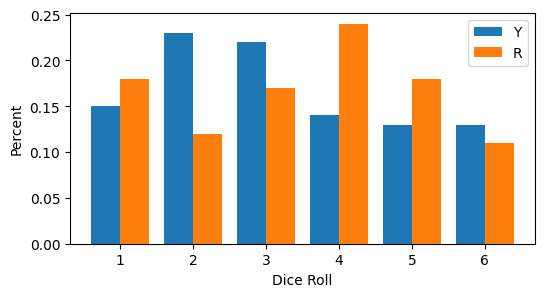

In [ ]:
y_counts = data["Y"].value_counts().sort_index().reindex(range(1, 7), fill_value=0) 
r_counts = data["R"].value_counts().sort_index().reindex(range(1, 7), fill_value=0)

y_density = y_counts / y_counts.sum()
r_density = r_counts / r_counts.sum()

x = np.arange(1, 7)
w = 0.4

plt.figure(figsize=(6, 3))
plt.bar(x - w/2, y_density, width=w, label="Y")
plt.bar(x + w/2, r_density, width=w, label="R")

plt.xticks(x)
plt.xlabel("Dice Roll")
plt.ylabel("Percent")
plt.legend()

plt.show()

$$\pi_e \leftarrow \pi_e\cdot e^{-\eta(\Psi(\theta_e)-\bar\Psi)}
$$